In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Resultados de los Modelos

In [3]:
# Diccionario con resultados de cada modelo
results = {
    'Modelo 1: RS Embeddings Only': {'R2': 0.6422, 'RMSE': 94.17, 'Features': 'Item embeddings (64-dim)'},
    'Modelo 2: Metadata Only': {'R2': -0.0875, 'RMSE': 164.17, 'Features': 'price, early_access, num_genres, num_tags, num_specs, has_sentiment (6-dim)'},
    'Modelo 3: RS Emb + Metadata': {'R2': 0.6436, 'RMSE': 93.99, 'Features': 'RS embeddings (64-dim) + metadata (6-dim)'},
    'Modelo 4: Review Text Embeddings': {'R2': -0.0248, 'RMSE': 159.37, 'Features': 'Sentence-Transformers all-MiniLM-L6-v2 (384-dim)'},
    'Modelo 5: Tag Embeddings': {'R2': -18.8602, 'RMSE': 23.82, 'Features': 'Sentence-Transformers all-MiniLM-L6-v2 (384-dim)'},
    'Modelo 6: Hybrid Collaborative-Content': {'R2': 0.3823, 'RMSE': 123.73, 'Features': 'RS (64-dim) + TF-IDF (100-dim) + numerical (2-dim)'},
    'Modelo 7: RS + Review Text Embeddings': {'R2': 0.9557, 'RMSE': 33.13, 'Features': 'RS (64-dim) + Review text embeddings (384-dim)'},
}

# Crear DataFrame
df_results = pd.DataFrame(results).T
df_results = df_results.reset_index()
df_results.columns = ['Modelo', 'R²', 'RMSE', 'Features']
df_results['Modelo_num'] = df_results['Modelo'].str.extract(r'(\d+)').astype(int)
df_results = df_results.sort_values('Modelo_num')

print("="*100)
print("COMPARACIÓN DE MODELOS - VALIDACIÓN TEMPORAL")
print("="*100)
print(df_results[['Modelo', 'R²', 'RMSE', 'Features']].to_string(index=False))
print("="*100)

COMPARACIÓN DE MODELOS - VALIDACIÓN TEMPORAL
                                Modelo       R²    RMSE                                                                    Features
          Modelo 1: RS Embeddings Only   0.6422   94.17                                                    Item embeddings (64-dim)
               Modelo 2: Metadata Only  -0.0875  164.17 price, early_access, num_genres, num_tags, num_specs, has_sentiment (6-dim)
           Modelo 3: RS Emb + Metadata   0.6436   93.99                                   RS embeddings (64-dim) + metadata (6-dim)
      Modelo 4: Review Text Embeddings  -0.0248  159.37                            Sentence-Transformers all-MiniLM-L6-v2 (384-dim)
              Modelo 5: Tag Embeddings -18.8602   23.82                            Sentence-Transformers all-MiniLM-L6-v2 (384-dim)
Modelo 6: Hybrid Collaborative-Content   0.3823  123.73                          RS (64-dim) + TF-IDF (100-dim) + numerical (2-dim)
 Modelo 7: RS + Review Text Emb

## Visualización Comparativa

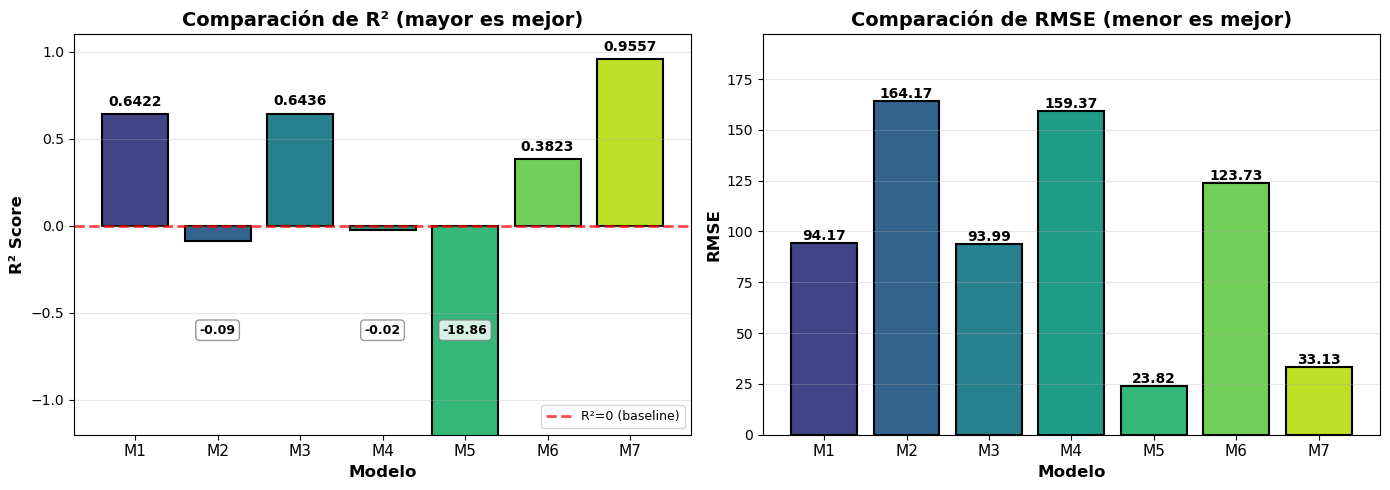


LEYENDA DE MODELOS:
M1: RS Embeddings Only - Item embeddings (64-dim)
M2: Metadata Only - price, early_access, num_genres, num_tags, num_specs, has_sentiment (6-dim)
M3: RS Emb + Metadata - RS embeddings (64-dim) + metadata (6-dim)
M4: Review Text Embeddings - Sentence-Transformers all-MiniLM-L6-v2 (384-dim)
M5: Tag Embeddings - Sentence-Transformers all-MiniLM-L6-v2 (384-dim)
M6: Hybrid Collaborative-Content - RS (64-dim) + TF-IDF (100-dim) + numerical (2-dim)
M7: RS + Review Text Embeddings - RS (64-dim) + Review text embeddings (384-dim)


In [6]:
# Crear gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colores para cada modelo
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df_results)))

# Plot 1: R² Score
bars1 = axes[0].bar(range(len(df_results)), df_results['R²'], color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación de R² (mayor es mejor)', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(df_results)))
axes[0].set_xticklabels([f"M{i+1}" for i in range(len(df_results))], fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='R²=0 (baseline)')

# Ajustar ylim: comprimir negativos, expandir positivos
max_r2 = max(df_results['R²'])
axes[0].set_ylim(-1.2, max_r2 * 1.15)  # Rango más equilibrado

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars1, df_results['R²'])):
    height = bar.get_height()
    if val >= 0:
        # Positivos: texto arriba de la barra
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.03,
                    f'{val:.4f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        # Negativos: texto dentro de la zona negativa, más arriba
        axes[0].text(bar.get_x() + bar.get_width()/2., -0.6,
                    f'{val:.2f}',
                    ha='center', va='center', fontsize=9, fontweight='bold', 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

axes[0].legend(loc='lower right', fontsize=9)

# Plot 2: RMSE
bars2 = axes[1].bar(range(len(df_results)), df_results['RMSE'], color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('Comparación de RMSE (menor es mejor)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(df_results)))
axes[1].set_xticklabels([f"M{i+1}" for i in range(len(df_results))], fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(df_results['RMSE']) * 1.2)

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars2, df_results['RMSE'])):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Leyenda de modelos
print("\n" + "="*100)
print("LEYENDA DE MODELOS:")
print("="*100)
for i, row in df_results.iterrows():
    print(f"M{row['Modelo_num']}: {row['Modelo'].split(': ')[1]} - {row['Features']}")
print("="*100)

## Análisis

### Observaciones principales:

1. **🏆 Modelo 7 (RS + Review Text)**: R² = 0.96 - BREAKTHROUGH
   - Combina señales colaborativas + semánticas de forma complementaria
   - RMSE = 33.13 (65% mejor que M1)
   - Feature importance: 49% RS + 51% Reviews (perfectamente balanceado)
   - **Insight clave**: Reviews SOLAS fallan (M4: R² = -0.02), pero COMBINADAS con RS mejoran dramáticamente

2. **Modelo 1 (RS Embeddings)**: R² = 0.64 - Excelente baseline
   - Los embeddings del sistema recomendador capturan patrones valiosos
   - RMSE = 94.17 reviews de error promedio

3. **Modelo 3 (RS + Metadata)**: R² = 0.64 - Mejora marginal
   - Metadata aporta muy poco sobre RS solo
   - RMSE = 93.99 (ligera mejora)

4. **Modelos de contenido puro (2, 4, 5)**: R² < 0 - Fallan completamente
   - Metadata, reviews, y tags NO predicen popularidad por sí solos
   - Capturan "qué ES el juego", no "cuán exitoso SERÁ"

### Descubrimiento principal:

**Las review embeddings tienen valor ORTOGONAL a RS embeddings:**
- RS captura "qué juega la gente" (patrones de comportamiento)
- Reviews captura "qué opina la gente" (percepción semántica)
- Separadas, reviews fallan (M4: R² = -0.02)
- Combinadas, son **altamente complementarias** (M7: R² = 0.96)
- Es como conocer el "vecindario conductual" Y las "características percibidas" del juego